In [4]:
from early_exit.early_exit import *
from shared.dataloaders import *
from shared.models import *
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Files already downloaded and verified
Files already downloaded and verified


In [5]:
MODEL_PATH = "early_exit/models/early_exit_vgg.pt"
DEVICE_MODEL_PATH = "early_exit/models/device.pth"
SERVER_MODEL_PATH = "early_exit/models/server.pth"

EPOCHS= 1

In [6]:
model = TwoStepVgg()
input_shape = (1,3, 32, 32)
eenet = EarlyExitNet(model.net,input_shape,device,[0.9])

In [7]:
# train(early_exit,EPOCHS,trainloader)

In [8]:
eenet.load_state_dict(torch.load(MODEL_PATH,map_location=device))

<All keys matched successfully>

In [10]:
test_accuracy(eenet,testloader)

Accuracy of exit 0: 60.99%
Accuracy of exit 1: 75.33%


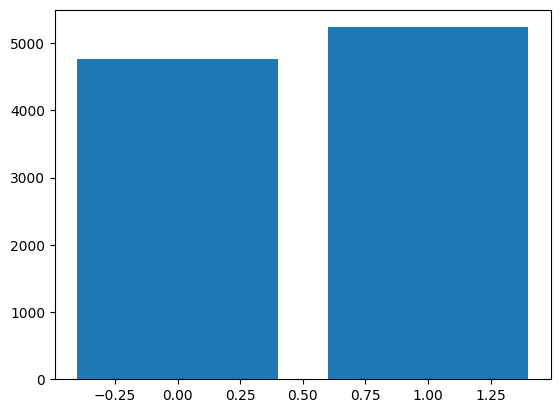

(tensor(0.6449), array([4762., 5238.]))

In [11]:
segmented_test_accuracy(eenet,testloader)

In [12]:
seperated_networks = seperate_networks(eenet)

In [13]:
edge_device_network = seperated_networks[0]
server_network = seperated_networks[1]

In [14]:
torch.save(edge_device_network,DEVICE_MODEL_PATH)
torch.save(server_network,SERVER_MODEL_PATH)

In [15]:
edge_device_network  = torch.load(DEVICE_MODEL_PATH)
server_network = torch.load(SERVER_MODEL_PATH)

In [16]:
for data,_ in testloader:
    batch = data.to(device)
    for sample in batch:
        output,exit_taken = edge_device_network(sample)
        print(output.shape,exit_taken)
        if not exit_taken:
            print('sent to netowrk')
            output,exit_taken = server_network(output)
            print(output.shape,exit_taken)


torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to netowrk
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([10]) True
torch.Size([128, 26, 26]) False
sent to neto